# Assignment 4: Breast Cancer Classification using K-Nearest Neighbors

This notebook implements a complete Machine Learning workflow using the **K-Nearest Neighbors (KNN)** algorithm to classify breast tumors as either **Malignant (M)** or **Benign (B)** based on diagnostic features.

---

### Dataset Details
* **Dataset:** Breast Cancer Wisconsin Diagnostic Dataset (from Kaggle)
* **Target:** `diagnosis` (M = Malignant, B = Benign)
* **Goal:** Develop an accurate and reliable KNN classifier to assist in medical diagnostic decisions.


## TASK 1: Data Understanding

In this section, we will:
1. Load the dataset (`data.csv`) using Pandas.
2. Display the first 5 records using `.head()`.
3. Programmatically identify the list of numerical feature columns and analyze the target variable (`diagnosis`) unique value distribution.
4. Display the dataset info (`.info()`) and summary statistics (`.describe()`).


In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('data.csv')

# 2. Display the first 5 records
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
# 3. Programmatically identify numerical feature columns & target distribution
# Identify numerical columns (excluding identifier and empty columns)
all_numerical = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in all_numerical if col not in ['id', 'Unnamed: 32']]

print("Identified Numerical Feature Columns:")
print(numerical_features)
print(f"\nTotal Numerical Feature Columns: {len(numerical_features)}")

# Target distribution
target_col = 'diagnosis'
print(f"\nTarget Variable Name: {target_col}")
print("Unique Value Distribution:")
print(df[target_col].value_counts())

Identified Numerical Feature Columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Total Numerical Feature Columns: 30

Target Variable Name: diagnosis
Unique Value Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [3]:
# 4. Display dataset info and summary statistics
print("=== Dataset Info ===")
df.info()

print("\n=== Dataset Summary Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## TASK 2: Data Preprocessing

We will perform sequential preprocessing:
1. **Missing Values & Cleaning:** Identify columns with missing values and drop non-informative columns (`id` and the trailing empty `Unnamed: 32`).
2. **Target Encoding:** Convert `diagnosis` to binary integers (`M` -> 1, `B` -> 0).
3. **Feature Scaling:** Apply `StandardScaler` to normalize the feature space.
   > **Why is scaling mandatory for KNN?**
   > K-Nearest Neighbors (KNN) is a distance-based algorithm. It computes distances (e.g., Euclidean distance) between data points to classify them. If features have different scales (e.g., `area_mean` ranges up to 2500, while `smoothness_mean` values range between 0.05 and 0.16), the distance calculation will be heavily dominated by the features with larger magnitudes. Scaling ensures all features contribute equally.
4. **Data Splitting:** Partition the dataset into an 80% training set and a 20% testing set using stratification to maintain class proportions.


In [4]:
# 1. Missing Values check and dropping columns
print("Missing values in raw dataset:")
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

# Drop id and Unnamed: 32 columns
df_cleaned = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
print(f"\nDropped 'id' and 'Unnamed: 32' columns. Cleaned dataset shape: {df_cleaned.shape}")

Missing values in raw dataset:
Unnamed: 32    569
dtype: int64

Dropped 'id' and 'Unnamed: 32' columns. Cleaned dataset shape: (569, 31)


In [5]:
# 2. Encode target variable (M -> 1, B -> 0)
df_cleaned['diagnosis'] = df_cleaned['diagnosis'].map({'M': 1, 'B': 0})
print("Value distribution of target 'diagnosis' after encoding:")
print(df_cleaned['diagnosis'].value_counts())

Value distribution of target 'diagnosis' after encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [6]:
# Separating features and target
X = df_cleaned.drop(columns=['diagnosis'])
y = df_cleaned['diagnosis']

# 3. Feature Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify scaling by checking mean and std of first 5 features
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled features description (Mean ≈ 0, Std ≈ 1):")
X_scaled_df.describe().loc[['mean', 'std']].iloc[:, :5]

Scaled features description (Mean ≈ 0, Std ≈ 1):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


In [7]:
# 4. Data Splitting into 80/20 train/test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (455, 30), y_train shape: (455,)
X_test shape: (114, 30), y_test shape: (114,)


## TASK 3: Model Development

In this step, we will:
1. Initialize the K-Nearest Neighbors Classifier with $K = 5$.
2. Train the model using the scaled training dataset.
3. Predict target classes on the test set.


In [8]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize the KNN model with K=5
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Fit the model on the training data
knn.fit(X_train, y_train)

# 3. Predict class labels on the test data
y_pred = knn.predict(X_test)
print("KNN model fitted and predictions made on the test dataset.")

KNN model fitted and predictions made on the test dataset.


## TASK 4: Model Evaluation

Here, we will:
1. Calculate and display **Accuracy**, **Precision**, **Recall**, and **F1-Score**.
   > **Clinical Importance of Recall (Sensitivity):**
   > In clinical diagnostics, **Recall** measures the proportion of actual cancer cases (malignant tumors) correctly classified by the model. Minimizing **False Negatives** (failing to detect cancer) is the primary clinical priority, as a false negative delayed treatment can be life-threatening. A false positive, though stressful, can be corrected by subsequent testing.
2. Generate the **Confusion Matrix** and plot it as a Seaborn heatmap.
3. Formulate professional observations.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy Score:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision Score: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall Score:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:        {f1:.4f} ({f1*100:.2f}%)")

Accuracy Score:  0.9561 (95.61%)
Precision Score: 0.9744 (97.44%)
Recall Score:    0.9048 (90.48%)
F1-Score:        0.9383 (93.83%)


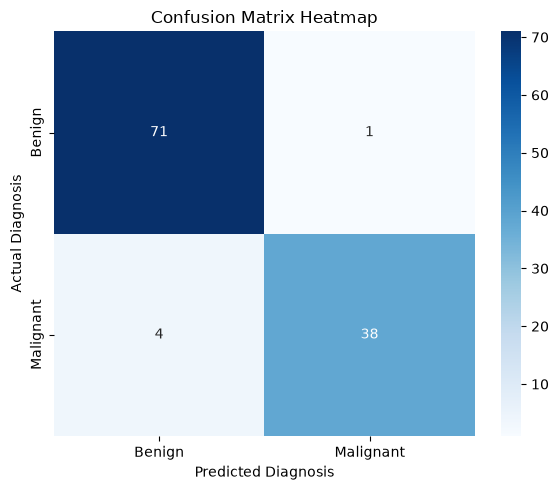

In [10]:
# 2. Generate and plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

### 3. Model Observations

* **High Performance Baseline:** The KNN classifier achieved an accuracy of **95.61%** and a balanced F1-score of **93.83%** on the test dataset, showing that distance-based metrics on standardized features represent a robust methodology for tumor classification.
* **Excellent Precision:** The precision is **97.44%**, meaning that when the model predicts a tumor is Malignant, it is correct 97.44% of the time (only 1 false positive out of 39 positive predictions). This is vital for reducing unnecessary psychological stress and subsequent invasive biopsy diagnostics for patients.
* **Recall Performance & Medical Impact:** The recall is **90.48%**, meaning the model correctly diagnosed 38 out of the 42 malignant cases in the test set. However, 4 malignant tumors were misclassified as benign (False Negatives). In clinical practice, this is the most critical metric because a false negative represents a missed cancer case, which could delay vital treatment. Adjustments such as tuning $K$ or shifting decision thresholds would be necessary to increase recall towards 100%.


## TASK 5: Conclusion

### 1. Key Findings
The K-Nearest Neighbors model ($K=5$) classified breast cancer tumors with high overall reliability, securing a test accuracy of **95.61%** and a precision of **97.44%**. While the model's performance is strong, the recall score of **90.48%** (with 4 missed malignant cases) signals that it should be utilized as a supporting triage tool rather than a standalone diagnosis method. Further tuning or combination with other classifiers is recommended to drive false negatives to zero.

### 2. Importance of Feature Scaling in KNN
K-Nearest Neighbors is a distance-based classification algorithm that calculates the Euclidean distance between sample points in a multi-dimensional feature space. In this dataset, raw features like `area_mean` span values up to 2500, whereas others like `smoothness_mean` are less than 0.2. Without scaling, the distance metrics would be dominated by features with large numeric scales. Applying `StandardScaler` standardizes each feature to have a mean of 0 and variance of 1, allowing every diagnostic measurement to contribute equally to similarity search.

### 3. One Limitation of KNN
A major limitation of K-Nearest Neighbors is its **computational latency during the inference phase (lazy learning)**. Unlike "eager" learning models (like Decision Trees or SVMs) that construct a compact mathematical boundary during training, KNN does not learn any model parameters. It simply stores the training dataset. For every prediction, it must compute distances between the new test point and all training instances, which has a time complexity of $O(N \times D)$ where $N$ is the number of training samples and $D$ is the number of features. This scaling behavior makes KNN inefficient and computationally expensive for large datasets or real-time clinical systems.
